Importing Libraries

In [35]:

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

Reading Dataset

In [36]:
data=pd.read_csv("bike_sales_india.csv")

Checking the values

In [37]:
data.head()
#data.info()


,State,Avg Daily Distance (km),Brand,Model,Price (INR),Year of Manufacture,Engine Capacity (cc),Fuel Type,Mileage (km/l),Owner Type,Registration Year,Insurance Status,Seller Type,Resale Price (INR),City Tier
0,Karnataka,68.84,Royal Enfield,Hunter 350,252816,2021,672,Electric,78.41,Second,2024,Active,Individual,149934.18,Tier 3
1,Rajasthan,23.80,Bajaj,Dominar 400,131100,2020,769,Hybrid,89.98,Third,2023,Active,Individual,66960.30,Tier 3
2,Madhya Pradesh,27.67,KTM,125 Duke,201016,2020,216,Hybrid,71.46,Second,2023,Active,Dealer,141522.64,Tier 3
3,Karnataka,62.85,Kawasaki,Ninja 300,132482,2021,556,Petrol,51.73,Third,2021,Active,Dealer,56057.22,Tier 1
4,Madhya Pradesh,10.62,Yamaha,FZ V3,231796,2019,298,Petrol,54.72,Third,2019,Not Available,Individual,132538.36,Tier 3


In [38]:
data.shape

(10000, 15)

Find missing values

In [39]:
data.isnull().sum()

State                      0
Avg Daily Distance (km)    0
Brand                      0
Model                      0
Price (INR)                0
Year of Manufacture        0
Engine Capacity (cc)       0
Fuel Type                  0
Mileage (km/l)             0
Owner Type                 0
Registration Year          0
Insurance Status           0
Seller Type                0
Resale Price (INR)         0
City Tier                  0
dtype: int64

Find duplicate values

In [40]:
data.duplicated().sum()

np.int64(0)

Select the features and target

In [41]:
X = data[['Year of Manufacture', 
          'Engine Capacity (cc)', 
          'Mileage (km/l)', 
          'Avg Daily Distance (km)']]
Y = data['Price (INR)']

Implementing Algorithm

In [42]:
model=LinearRegression()

Train model

In [43]:
model.fit(X,Y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[-99.89, 0.39, 2. , 56.62]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Year of Manufacture','Engine Capacity (cc)','Mileage (km/l)', 'Avg Daily Distance (km)']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.233e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,4


Getting the details of bike from user and predict the price

In [44]:
new_bike = pd.DataFrame(
    [[2024, 456, 67, 34]],
    columns=['Year of Manufacture', 
             'Engine Capacity (cc)', 
             'Mileage (km/l)', 
             'Avg Daily Distance (km)']
)

prediction = model.predict(new_bike)
print(f"Predicted Price: {prediction[0]:.2f}")

Predicted Price: 223359.32


SCATTER PLOT -> YEAR OF MANUFACTURE VS AVG PRICE

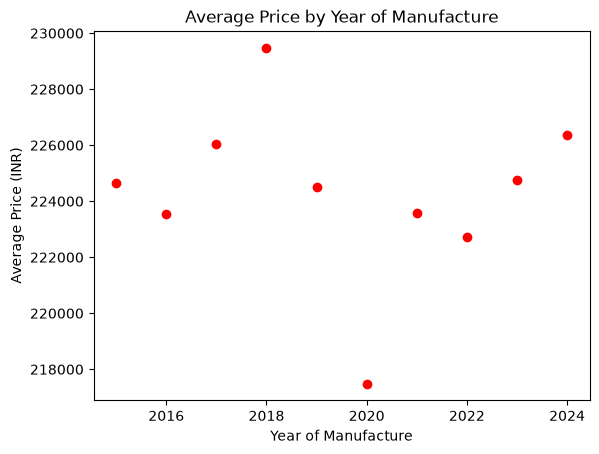

In [45]:
avg_price = data.groupby('Year of Manufacture')['Price (INR)'].mean()

plt.scatter(avg_price.index, avg_price.values, color="red")
plt.xlabel('Year of Manufacture')
plt.ylabel('Average Price (INR)')
plt.title('Average Price by Year of Manufacture')
plt.show()

BAR CHART -> ENGINE CAPACITY VS PRICE

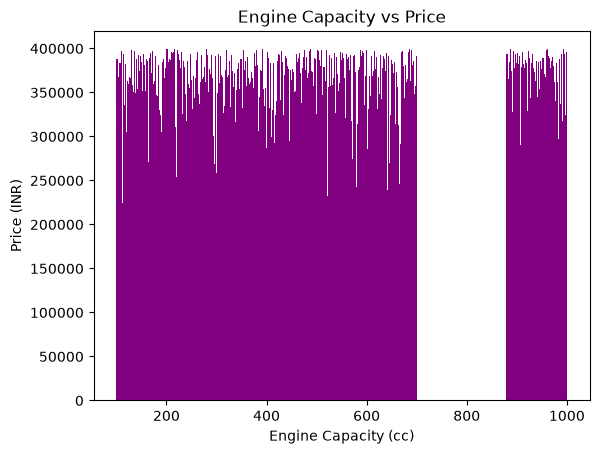

In [46]:
plt.bar(data['Engine Capacity (cc)'], data['Price (INR)'], color="purple")
plt.xlabel('Engine Capacity (cc)')
plt.ylabel('Price (INR)')
plt.title('Engine Capacity vs Price')
plt.show()

LINE PLOT -> BRAND VS AVG PRICE

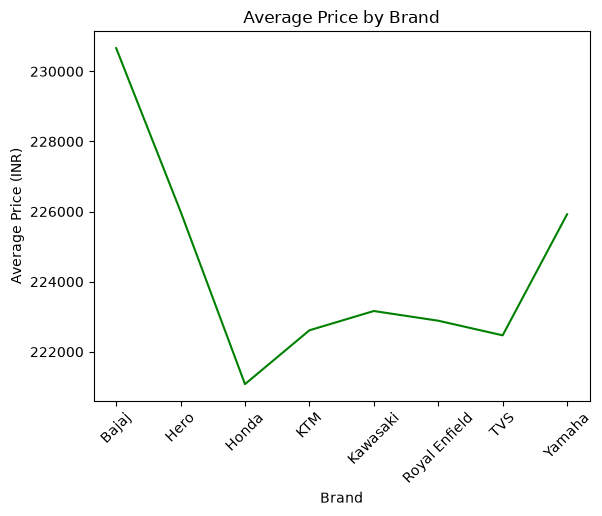

In [47]:
grouped = data.groupby('Brand')['Price (INR)'].mean()
plt.plot(grouped.index, grouped.values, color="green")
plt.xticks(rotation=45)
plt.xlabel('Brand')
plt.ylabel('Average Price (INR)')
plt.title('Average Price by Brand')
plt.show()